In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install -U transformers accelerate
!pip -q install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 155.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.5 MB/s eta 0:00:00


In [1]:
# Import libraries

from datasets import Dataset
from pandas import to_pickle
from datasets import load_from_disk
import pandas as pd
import json
from re import compile
import os

In [2]:

#Load the dataset - Australian Legal QA

qa_train = load_from_disk('/content/drive/MyDrive/Colab Notebooks/India/AusLegal_train_dataset')
qa_eval = load_from_disk('/content/drive/MyDrive/Colab Notebooks/India/AusLegal_val_dataset')

print(len(qa_train))
print(len(qa_eval))


1695
427


In [3]:
# LOAD CORPUS of all passages or regulatory documents
import pickle
corpus_path = "/content/drive/MyDrive/Colab Notebooks/India/auscorpus.pkl"
with open(corpus_path, "rb") as f:
    corpus = pickle.load(f)

print(f"Loaded corpus with {len(corpus)} passages")


Loaded corpus with 2114 passages


# Retrival of Top K answers with Entail Hard Neg Tuned Model




In [4]:
import json

with open("/content/drive/MyDrive/Colab Notebooks/India/OpenAushybrid_top10_filtered.json") as f:
    top_k_results = json.load(f)

Gemme Answer generation

In [5]:
from huggingface_hub import login # used only sometimes mainly Gemme
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

# 4-bit quantization config (same as yours, but fixed dtype)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

model_name = "google/gemma-3-12b-it"

# tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    quantization_config=bnb_config,
    trust_remote_code=True
)

# important for generation stability
model.eval()

config.json:   0%|          | 0.00/916 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Gemma3ForConditionalGeneration(
  (model): Gemma3Model(
    (vision_tower): SiglipVisionModel(
      (vision_model): SiglipVisionTransformer(
        (embeddings): SiglipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
          (position_embedding): Embedding(4096, 1152)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-26): 27 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
                (v_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
                (q_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
                (out_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
              )
              (layer_norm2): LayerNorm((1152,), eps=

In [7]:
# prompt used for answer generation

def build_prompt(question, passages):
    context_chunks = []

    for p in passages:
        text = p.get("text")

        if isinstance(text, dict):
            # pick the actual content field safely
            if "content" in text:
                context_chunks.append(text["content"])
            elif "raw_text" in text:
                context_chunks.append(text["raw_text"])
            else:
                context_chunks.append(str(text))  # fallback
        else:
            context_chunks.append(str(text))

    context = "\n\n".join(context_chunks)

    prompt = (
        "You are a regulatory compliance assistant. Provide a detailed answer for the question that "
        "fully integrates all the obligations and best practices from the given passages. Ensure your "
        "response is cohesive and directly addresses the question. Synthesize the information from all "
        "passages into a single, unified answer.\n\n"

        "Now answer the following question:\n\n"
        f"Question: {question}\n\n"
        f"Context:\n{context}\n\n"
        "Answer:"
    )

    return prompt

In [8]:
# Prepare qa_eval_dict (anchor_id → gold answer) qa_eval_dict → map of qid to gold answer (we’ll prepare this too)

qa_eval_dict = {item["question_id"]: item["answer"] for item in qa_eval}

In [9]:
from transformers import pipeline
import json

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

generated_answers = {}
count = 0

for qid, entry in list(top_k_results.items())[:150]:
    question = entry["question"]
    passages = entry.get("filtered_passages", [])

    if not passages:
        continue  # skip if no filtered context

    prompt = build_prompt(question, passages)

    response = generator(prompt,max_new_tokens=512,do_sample=False,return_full_text=False)[0]["generated_text"]

    answer_text = response.split("Answer:")[-1].strip()

    generated_answers[qid] = {
        "question": question,
        "generated_answer": answer_text,
        "expected_answer": qa_eval_dict.get(qid, ""),
        "context_passages": passages
    }

    count += 1
    if count % 10 == 0:
        print(f"Generated answers for {count} questions...")

# Save to file for RePAS evaluation
output_path = "/content/drive/MyDrive/Colab Notebooks/India/ZeroShotGemme3B_AusOpen_GenAns.json"
with open(output_path, "w") as f:
    json.dump(generated_answers, f, indent=2)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_token

Generated answers for 10 questions...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Generated answers for 20 questions...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Generated answers for 130 questions...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Generated answers for 140 questions...


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Generated answers for 150 questions...


In [10]:
import json

save_path =  "/content/drive/MyDrive/Colab Notebooks/India/ZeroShotGemme3B_AusOpen_GenAns.json"
with open(save_path, "r") as f:
    qwen_outputs = json.load(f)

print(f"Total generated answers so far: {len(qwen_outputs)}")

Total generated answers so far: 150


# Repass Score calaculation for answers generated

In [11]:
import json

# Load original qwen-style output
with open("/content/drive/MyDrive/Colab Notebooks/India/ZeroShotGemme3B_AusOpen_GenAns.json", "r") as f:
    raw_data = json.load(f)

converted_data = []

for uuid, content in raw_data.items():
    question_id = uuid
    passages = [p["text"] for p in content.get("context_passages", [])]
    answer = content.get("generated_answer", "")

    # Skip empty answers just like the original script does
    if not answer.strip():
        continue

    converted_data.append({
        "QuestionID": question_id,
        "RetrievedPassages": passages,
        "Answer": answer
    })

# Save to file
with open("/content/drive/MyDrive/Colab Notebooks/India/ZeroShotGemme3B_AusOpen_FormatAns.json", "w") as f:
    json.dump(converted_data, f, indent=2)

In [12]:
import sys
sys.argv = [
    "",  # program name placeholder
    "--input_file", "/content/drive/MyDrive/Colab Notebooks/India/ZeroShotGemme3B_AusOpen_FormatAns.json",
    "--group_method_name", "/content/drive/MyDrive/Colab Notebooks/India/ZeroShotGemme3BAusOpen_topk10"
]

In [13]:
# Repass score calculation

import json
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from nltk.tokenize import sent_tokenize as sent_tokenize_uncached
import nltk
from functools import cache
import tqdm
import os
import csv

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)



# Set up device for torch operations
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Correct path to the trained model and tokenizer
model_name = '/content/drive/MyDrive/Colab Notebooks/eval/RePAS/models/obligation-classifier-legalbert'

# Load the tokenizer and model for obligation detection
obligation_tokenizer = AutoTokenizer.from_pretrained(model_name)
obligation_model = AutoModelForSequenceClassification.from_pretrained(model_name)
obligation_model.to(device)
obligation_model.eval()


use_cuda = torch.cuda.is_available()
pipe_device = 0 if use_cuda else -1
coverage_nli_model = pipeline(
    "text-classification",
    model="microsoft/deberta-large-mnli",
    device=pipe_device,
    return_all_scores=True,
    truncation=True
)



# Load NLI model and tokenizer for obligation coverage using Microsoft's model
#coverage_nli_model = pipeline("text-classification", model="microsoft/deberta-large-mnli", device=device)

# Load NLI model and tokenizer for entailment and contradiction checks
nli_tokenizer = AutoTokenizer.from_pretrained('cross-encoder/nli-deberta-v3-xsmall')
nli_model = AutoModelForSequenceClassification.from_pretrained('cross-encoder/nli-deberta-v3-xsmall')
nli_model.to(device)
nli_model.eval()

# Define a cached version of sentence tokenization
@cache
def sent_tokenize(passage: str):
    return sent_tokenize_uncached(passage)

def softmax(logits):
    e_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return e_logits / np.sum(e_logits, axis=1, keepdims=True)

def get_nli_probabilities(premises, hypotheses):
    features = nli_tokenizer(premises, hypotheses, padding=True, truncation=True, return_tensors="pt").to(device)
    nli_model.eval()
    with torch.no_grad():
        logits = nli_model(**features).logits.cpu().numpy()
    probabilities = softmax(logits)
    return probabilities

def get_nli_matrix(passages, answers):
    entailment_matrix = np.zeros((len(passages), len(answers)))
    contradiction_matrix = np.zeros((len(passages), len(answers)))

    batch_size = 16
    for i, pas in enumerate(tqdm.tqdm(passages)):
        for b in range(0, len(answers), batch_size):
            e = b + batch_size
            probs = get_nli_probabilities([pas] * len(answers[b:e]), answers[b:e])  # Get NLI probabilities
            entailment_matrix[i, b:e] = probs[:, 2]   # entailment
            contradiction_matrix[i, b:e] = probs[:, 0]
    return entailment_matrix, contradiction_matrix

def calculate_scores_from_matrix(nli_matrix, score_type='entailment'):
    if nli_matrix.size == 0:
        return 0.0
    return np.round(np.mean(np.max(nli_matrix, axis=0)), 5)

def classify_obligations(sentences):
    inputs = obligation_tokenizer(sentences, padding=True, truncation=True, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = obligation_model(**inputs).logits
    predictions = torch.argmax(logits, dim=1).cpu().numpy()
    return predictions

def calculate_obligation_coverage_score(passages, answers):
    # --------------------------------------------------
    # 1. Extract obligation sentences from passages
    # --------------------------------------------------
    obligation_sentences_source = []

    for passage in passages:
        sentences = sent_tokenize(passage)
        is_obligation = classify_obligations(sentences)

        obligation_sentences_source.extend([
            sent for sent, label in zip(sentences, is_obligation) if label == 1
        ])

    # --------------------------------------------------
    # 2. Use ALL answer sentences (IMPORTANT FIX)
    # --------------------------------------------------
    answer_sentences = []

    for answer in answers:
        answer_sentences.extend(sent_tokenize(answer))

    # Safety fallback (in case tokenization fails)
    if not answer_sentences:
        answer_sentences = answers

    # --------------------------------------------------
    # 3. Compute coverage using NLI entailment
    # --------------------------------------------------
    covered_count = 0

    for obligation in obligation_sentences_source:
        best_ent = 0.0

        for answer_sentence in answer_sentences:
            scores = coverage_nli_model({
                "text": obligation,
                "text_pair": answer_sentence
            })

            # Normalize pipeline output
            if isinstance(scores, dict):
                scores = [scores]
            elif isinstance(scores, list) and len(scores) > 0 and isinstance(scores[0], list):
                scores = scores[0]

            # Extract entailment score safely
            ent = 0.0
            for d in scores:
                if isinstance(d, dict):
                    label = d.get("label", "").upper()
                    if label in ("ENTAILMENT", "LABEL_2"):
                        ent = float(d.get("score", 0.0))
                        break

            best_ent = max(best_ent, ent)

        # Threshold (slightly relaxed for stability)
        if best_ent > 0.6:
            covered_count += 1

    # --------------------------------------------------
    # 4. Final coverage score
    # --------------------------------------------------
    if not obligation_sentences_source:
        return 1.0  # no obligations → no penalty

    return covered_count / len(obligation_sentences_source)


def calculate_final_composite_score(passages, answers):
    passage_sentences = [sent for passage in passages for sent in sent_tokenize(passage)]
    answer_sentences = [sent for answer in answers for sent in sent_tokenize(answer)]
    entailment_matrix, contradiction_matrix = get_nli_matrix(passage_sentences, answer_sentences)
    entailment_score = calculate_scores_from_matrix(entailment_matrix, 'entailment')
    contradiction_score = calculate_scores_from_matrix(contradiction_matrix, 'contradiction')
    obligation_coverage_score = calculate_obligation_coverage_score(passages, answers)

    composite_score = (obligation_coverage_score + entailment_score - contradiction_score + 1) / 3
    return np.round(composite_score, 5), entailment_score, contradiction_score, obligation_coverage_score

def main(input_file_path, group_method_name):
    # Create a directory with the group_method_name in the data folder
    output_dir = f'./data/{group_method_name}'
    os.makedirs(output_dir, exist_ok=True)

    # Define the paths for result files
    output_file_csv = os.path.join(output_dir, 'results.csv')
    output_file_txt = os.path.join(output_dir, 'results.txt')

    processed_question_ids = set()
    composite_scores = []
    entailment_scores = []
    contradiction_scores = []
    obligation_coverage_scores = []

    # Check if the output CSV file already exists and read processed QuestionIDs
    if os.path.exists(output_file_csv):
        with open(output_file_csv, 'r') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                processed_question_ids.add(row['QuestionID'])

    with open(input_file_path, 'r') as file:
        test_data = json.load(file)

    # Open the CSV file for appending results
    with open(output_file_csv, 'a', newline='') as csvfile:
        writer = csv.writer(csvfile)
        if not processed_question_ids:
            # Write the header if the file is empty or new
            writer.writerow(['QuestionID', 'entailment_score', 'contradiction_score', 'obligation_coverage_score', 'composite_score'])

        for item in tqdm.tqdm(test_data):
            question_id = item['QuestionID']

            # Skip if the QuestionID has already been processed
            if question_id in processed_question_ids:
                print(f"Skipping QuestionID {question_id}, already processed.")
                continue

            # Skip if the "Answer" is null or empty
            if not item.get('Answer') or not item['Answer'].strip():
                print(f"Skipping QuestionID {question_id}, no answer.")
                continue

            # Merge "RetrievedPassages" if it's a list
            if isinstance(item['RetrievedPassages'], list):
                if isinstance(item["RetrievedPassages"], list):
                    texts = []
                    for p in item["RetrievedPassages"]:
                        if isinstance(p, dict):
                            # choose the correct field
                            if "text" in p:
                                texts.append(p["text"])
                            elif "content" in p:
                                texts.append(p["content"])
                            else:
                                texts.append(str(p))  # fallback
                        else:
                            texts.append(str(p))

                    item["RetrievedPassages"] = " ".join(texts)

            passages = [item['RetrievedPassages']]
            answers = [item['Answer']]
            composite_score, entailment_score, contradiction_score, obligation_coverage_score = calculate_final_composite_score(passages, answers)

            # Append the scores to the lists
            composite_scores.append(composite_score)
            entailment_scores.append(entailment_score)
            contradiction_scores.append(contradiction_score)
            obligation_coverage_scores.append(obligation_coverage_score)

            # Write the result to the CSV file
            writer.writerow([question_id, entailment_score, contradiction_score, obligation_coverage_score, composite_score])

    # Calculate averages
    avg_entailment = np.mean(entailment_scores)
    avg_contradiction = np.mean(contradiction_scores)
    avg_obligation_coverage = np.mean(obligation_coverage_scores)
    avg_composite = np.mean(composite_scores)

    # Print and save results to a text file
    results = (
        f"Average Entailment Score: {avg_entailment}\n"
        f"Average Contradiction Score: {avg_contradiction}\n"
        f"Average Obligation Coverage Score: {avg_obligation_coverage}\n"
        f"Average Final Composite Score: {avg_composite}\n"
    )

    print(results)

    with open(output_file_txt, 'w') as txtfile:
        txtfile.write(results)

    print(f"Processing complete. Results saved to {output_dir}")

if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(description="Evaluate Obligation Coverage")
    parser.add_argument('--input_file', type=str, required=True, help='Path to the input JSON file')
    parser.add_argument('--group_method_name', type=str, required=True, help='Method name for grouping results')

    args = parser.parse_args()

    main(args.input_file, args.group_method_name)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File 

...

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/283M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-xsmall
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 150/150 [21:31<00:00,  8.61s/it]

Average Entailment Score: 0.9637934000000001
Average Contradiction Score: 0.5154506666666666
Average Obligation Coverage Score: 0.2371264545253494
Average Final Composite Score: 0.5618232666666665

Processing complete. Results saved to ./data//content/drive/MyDrive/Colab Notebooks/India/ZeroShotGemme3BAusOpen_topk10


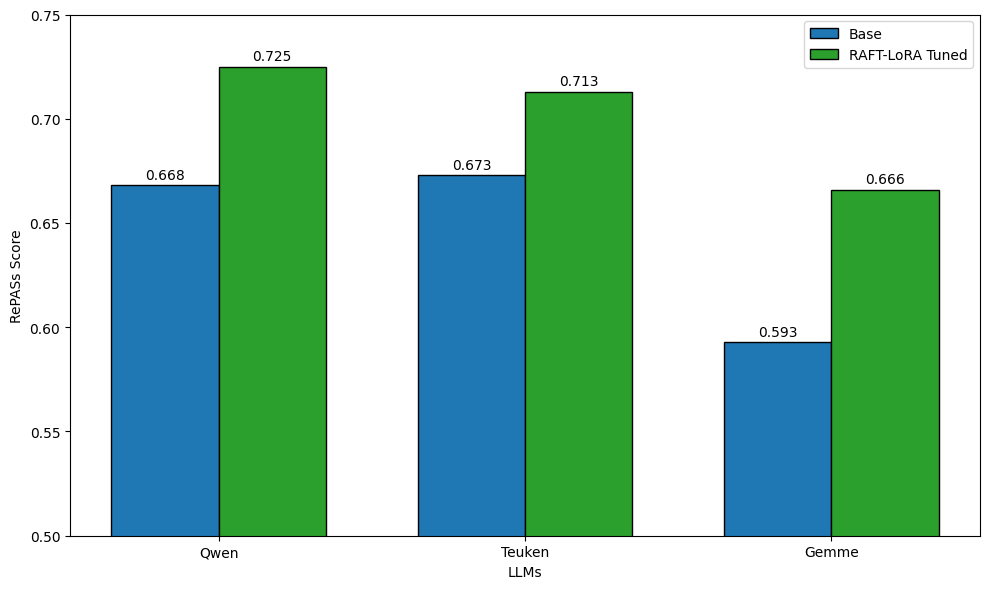

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["Qwen", "Teuken", "Gemme"]
base_scores = [0.668, 0.673, 0.593]
raft_scores = [0.725, 0.713, 0.666]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, base_scores, width,
        label="Base",
        color='#1F77B4',   # strong blue
        edgecolor='black')

plt.bar(x + width/2, raft_scores, width,
        label="RAFT-LoRA Tuned",
        color='#2CA02C',   # strong green
        edgecolor='black')

# Labels
plt.xlabel("LLMs")
plt.ylabel("RePASs Score")
plt.xticks(x, models)
plt.legend()

# 🔥 IMPORTANT: Zoomed Y-axis
plt.ylim(0.5, 0.75)

# Value labels
for i in range(len(models)):
    plt.text(x[i] - width/2, base_scores[i] + 0.003, f"{base_scores[i]:.3f}", ha='center')
    plt.text(x[i] + width/2, raft_scores[i] + 0.003, f"{raft_scores[i]:.3f}", ha='center')

plt.tight_layout()
plt.savefig("repass_grouped_bar_zoomed.png", dpi=300)
plt.show()

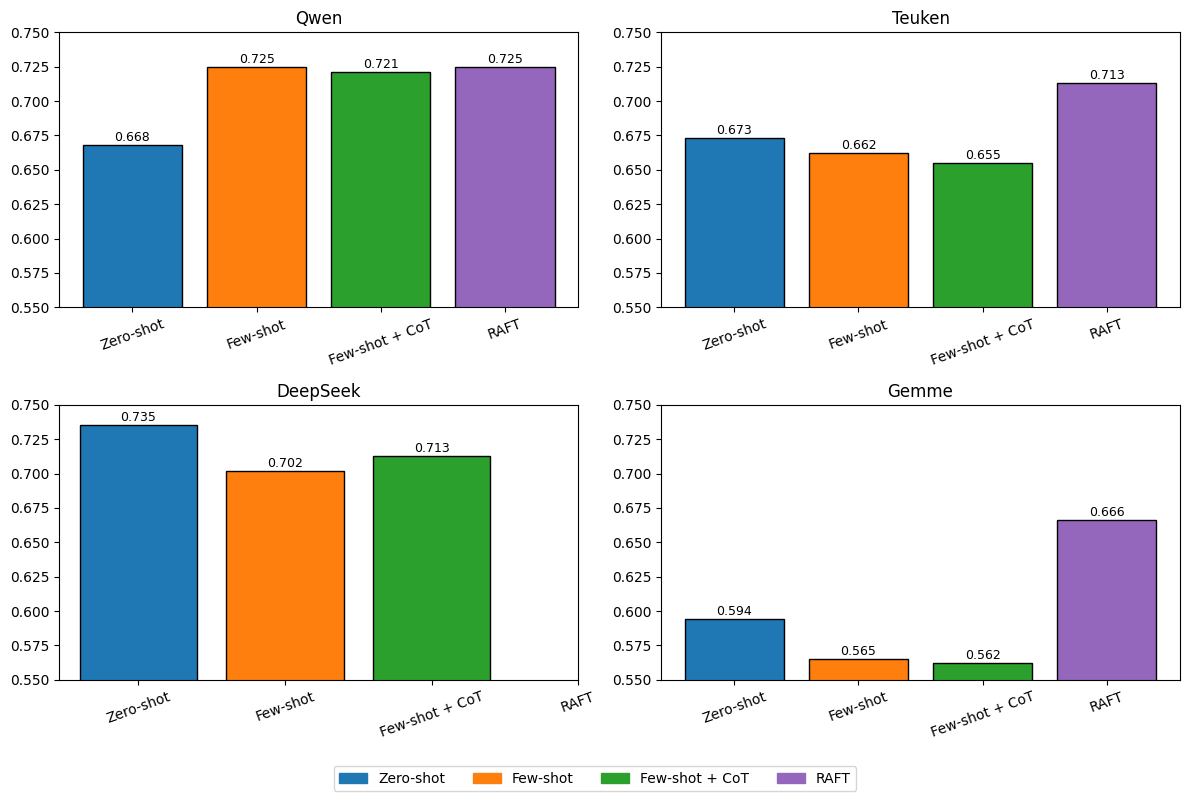

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
strategies = ["Zero-shot", "Few-shot", "Few-shot + CoT", "RAFT"]

data = {
    "Qwen": [0.668, 0.725, 0.721, 0.725],
    "Teuken": [0.673, 0.662, 0.655, 0.713],  # None for missing value
    "DeepSeek": [0.735, 0.702, 0.713, None],
    "Gemme": [0.594, 0.565, 0.562, 0.666]
}

# Colors for strategies
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#9467BD']
# blue, orange, green, red

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (model, scores) in enumerate(data.items()):
    ax = axes[i]
    x = np.arange(len(strategies))

    for j, (s, color) in enumerate(zip(scores, colors)):
        if s is not None:
            ax.bar(j, s, color=color, edgecolor='black')
            ax.text(j, s + 0.003, f"{s:.3f}", ha='center', fontsize=9)

    ax.set_title(model)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, rotation=20)
    ax.set_ylim(0.55, 0.75)


# Legend (common for all plots)
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
fig.legend(handles, strategies, loc='lower center', ncol=4)


plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("prompting_strategies_colored.png", dpi=300)
plt.show()